In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
class MLP_MINST(nn.Module):
    def __init__(self):
        super().__init__()

        self.mlp_stack = nn.Sequential(
            nn.Linear(784,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,10)
        )
    def foward(self,x):
        x = x.view(x.shape[0],-1)
        return self.mlp_stack(x)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
model = MLP_MINST().to(device)

cpu


In [6]:
tranform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),

])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=tranform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=tranform
)

train_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False
)

torch.Size([128, 1, 28, 28])


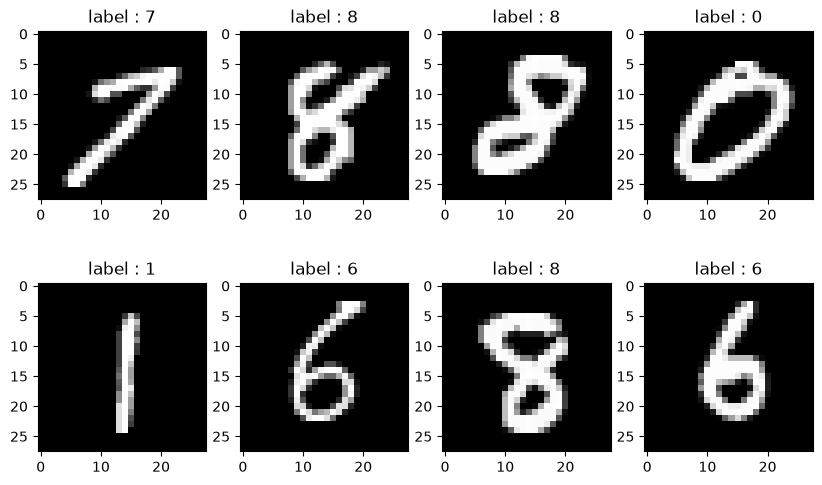

In [16]:
images,lables = next(iter(train_loaders))
print(images.shape)
plt.figure(figsize=(10,6))
for i in range(8):
    image = images[i]
    image = image.permute(1,2,0)
    label = lables[i]
    plt.subplot(2,4,i+1)
    plt.imshow(image,cmap='gray')
    plt.title(f"label : {label}")
    

In [17]:
#Hyper-paramaeters
nums_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [ ]:
def train_loop(model,train_loader,criterion,optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images,labels in train_loader:
        images = image.to(device)
        labels = lables.to(device)

        #prediction
        logits = model(images)

        #compute Loss
        loss = criterion(logits,labels)

        #backpropogation

        optimizer.zero_grad()
        loss.backward()

        #weight update
        optimizer.step()

        running_loss+=loss.item()